# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [ ]:
# ── 기본 ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# ── 결측치 처리 (Day 4-1) ──
from sklearn.impute import SimpleImputer, KNNImputer

# ── 전처리·분할·스케일링·인코딩 ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# ── 평가 지표 ──
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── 시각화·차원 축소 (Day 4-2) ──
from sklearn.manifold import TSNE

# ── Resampling (Day 4-2) ──
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

# ── One-Class Learning / SVDD (Day 4-3) ──
from sklearn.svm import OneClassSVM

# ── 분류 모델 (Resampling 성능 비교) ──
from xgboost import XGBClassifier

In [4]:
# ── 데이터 로드 및 구조 확인 ──
churn_data = pd.read_csv("dataset/day4_miniproject.csv")
print("데이터 크기:", churn_data.shape)
churn_data.head()

데이터 크기: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

1. 기본 구조
행·열: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,Male,0,No,No,66.0,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No



2. 데이터 타입·메모리


,dtype
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,float64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str
OnlineBackup,str


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   6903 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     6832 non-null   str    
 17  Monthl

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0000,0.000,0.0000,1.00
tenure,6832.0,32.376903,24.570605,0.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,6832.0,64.758255,30.077758,18.25,35.5875,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80



4. 결측치 현황


,missing,missing(%)
tenure,211,3.00
PaymentMethod,211,3.00
MonthlyCharges,211,3.00
InternetService,140,1.99
TotalCharges,11,0.16



5. 중복 행
완전 중복 행: 18개

6. 타겟 변수 (Churn) 분포 — 클래스 불균형
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


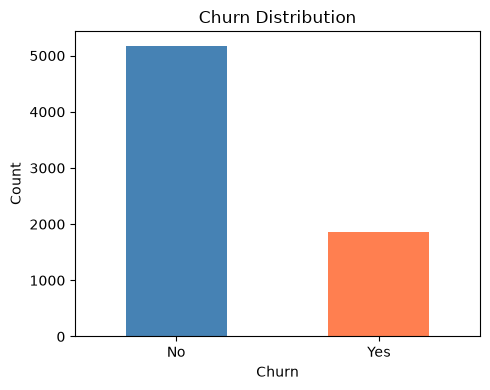


7. 범주형 변수 요약


,n_unique
gender,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
MultipleLines,3
OnlineSecurity,3
InternetService,3
OnlineBackup,3
DeviceProtection,3



8. 수치형 변수 분포


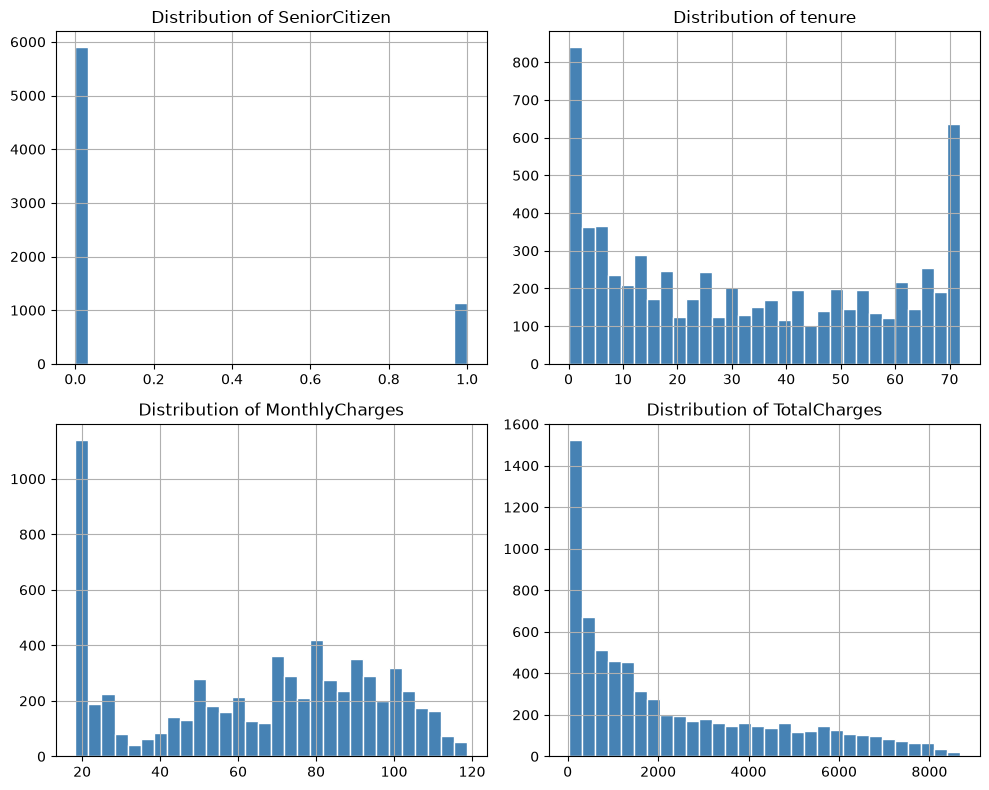


9. 수치형 변수 상관관계


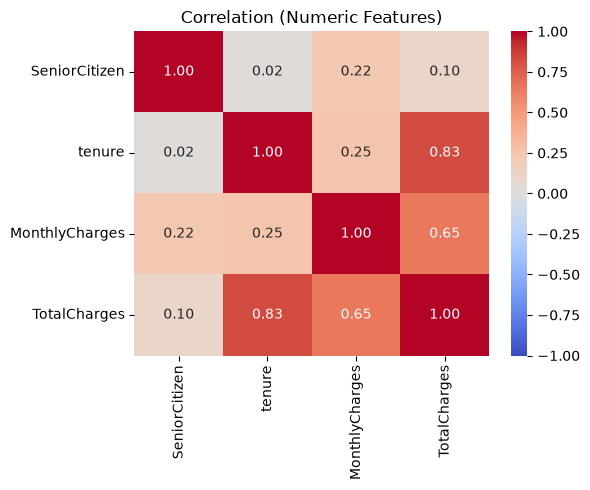

In [7]:

print("=" * 60)
print("1. 기본 구조")
print("=" * 60)
print(f"행·열: {churn_data.shape}")
print(f"\n컬럼 목록:\n{churn_data.columns.tolist()}")
display(churn_data.head())
display(churn_data.tail())

print("\n" + "=" * 60)
print("2. 데이터 타입·메모리")
print("=" * 60)
display(churn_data.dtypes.to_frame("dtype"))
churn_data.info()

print("\n" + "=" * 60)
print("3. 기초 통계 (수치형)")
print("=" * 60)
display(churn_data.describe().T)

print("\n" + "=" * 60)
print("4. 결측치 현황")
print("=" * 60)
missing = churn_data.isnull().sum()
missing_pct = (missing / len(churn_data) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "missing(%)": missing_pct})
display(missing_df[missing_df["missing"] > 0].sort_values("missing", ascending=False))

print("\n" + "=" * 60)
print("5. 중복 행")
print("=" * 60)
print(f"완전 중복 행: {churn_data.duplicated().sum()}개")

print("\n" + "=" * 60)
print("6. 타겟 변수 (Churn) 분포 — 클래스 불균형")
print("=" * 60)
print(churn_data["Churn"].value_counts())
print()
print(churn_data["Churn"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
churn_data["Churn"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("7. 범주형 변수 요약")
print("=" * 60)
cat_cols = churn_data.select_dtypes(include=["object", "string"]).columns.drop("Churn", errors="ignore")
nunique_df = churn_data[cat_cols].nunique().sort_values().to_frame("n_unique")
display(nunique_df)

print("\n" + "=" * 60)
print("8. 수치형 변수 분포")
print("=" * 60)
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), num_cols):
    churn_data[col].dropna().hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("9. 수치형 변수 상관관계")
print("=" * 60)
corr = churn_data[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation (Numeric Features)")
plt.tight_layout()
plt.show()


[프롬프트]
EDA결과를 봤을 때 내 생각에는 아래와 같은 전처리에 대해 고민이 필요해보여.
1. 출력변수 Churn은 No:0, Yes:1로 인코딩 필요. 우리는 이탈 고객에 관심이 있으니까.
2. 수치형 변수로 분류된 'SeniorCitizen'은 사실 범주형으로 보임. 이 밖에 다른 범주형 변수들을 0,1,2와 같은 숫자로 인코딩 할 필요가 있는지 궁금해.
3. 변수간 상관관계 분석에서 'MonthlyCharges'와 'tenure'는 0.83의 높은 상관도를 보이고 있어. 이 변수가 의미하는 바는 뭘까? 그리고 혹시 하나의 변수만 남기는 것이 좋을까?

## EDA 기반 전처리 고민 — 답변

### 1. Churn → No:0, Yes:1 인코딩

**맞습니다. 그렇게 하는 것이 좋습니다.**

- **Yes(이탈) = 1** → 우리가 찾고 싶은 **양성 클래스(이탈 고객)**
- **No(유지) = 0**

이렇게 하면 Recall, Precision, F1에서 **“이탈을 얼마나 잘 잡았는지”** 해석이 자연스럽고, SMOTE·`class_weight`·SVDD 평가와도 맞습니다.

```python
churn_data["Churn"] = churn_data["Churn"].map({"No": 0, "Yes": 1})
```

---

### 2. SeniorCitizen과 다른 범주형 변수 인코딩

#### SeniorCitizen

**범주형 성격이 맞지만, 이미 0/1이라 그대로 써도 됩니다.**

- 0 = 비시니어, 1 = 시니어 → **이진 범주**를 숫자로 표현한 것
- 굳이 문자열로 바꿀 필요는 없음

#### 다른 범주형 변수들

**대부분 `0, 1, 2`처럼 순서 있는 숫자로 바꾸면 안 됩니다.**

| 변수 예시 | 성격 | 추천 인코딩 |
|----------|------|------------|
| `gender`, `Partner`, `Dependents`, `PhoneService` 등 | 명목형(순서 없음) | **One-Hot Encoding** |
| `Contract` (Month-to-month → One year → Two year) | 순서 있음 | **Ordinal** 가능하나, One-Hot도 무방 |
| `InternetService`, `PaymentMethod` | 명목형 | **One-Hot** |

**Label Encoding(0, 1, 2…)을 피하는 이유**

- 모델이 `Fiber optic=2`, `DSL=1`처럼 **크기·순서가 있다**고 잘못 학습할 수 있음
- 특히 선형 모델, SVM, 거리 기반 방법에서 문제가 됨

**예외:** `Partner`, `Dependents`처럼 **Yes/No 이진**은 `Yes=1, No=0` 매핑해도 괜찮음 (One-Hot과 결과 동일).

**실무 추천:** 범주형은 **One-Hot** → 이후 **StandardScaler**는 수치형만 적용.

---

### 3. 상관관계 — 변수 의미와 제거 여부

#### 상관계수 확인

히트맵을 다시 보면, **0.83에 가까운 쌍은 `tenure` ↔ `TotalCharges`** 입니다.

| 변수 쌍 | 상관계수 (대략) |
|--------|----------------|
| **tenure ↔ TotalCharges** | **~0.83** (매우 높음) |
| MonthlyCharges ↔ TotalCharges | ~0.65 |
| **MonthlyCharges ↔ tenure** | **~0.25** (낮음) |

`MonthlyCharges`와 `tenure`가 0.83이라기보다, **`tenure`와 `TotalCharges`가 ~0.83**에 가깝습니다.

#### 각 변수가 의미하는 것

| 변수 | 의미 |
|------|------|
| **tenure** | 가입 기간(개월 수) — 얼마나 오래 이용했는지 |
| **MonthlyCharges** | **한 달 요금** — 요금제·서비스 수준 |
| **TotalCharges** | **누적 총 요금** — 대체로 tenure × 월요금 수준과 연관 |

**TotalCharges**는 tenure와 MonthlyCharges 정보가 많이 겹칩니다. (가입한 지 오래됐으면 누적 요금도 커지기 쉬움)

#### 하나만 남길까?

**절대 “무조건 하나 제거”는 아닙니다.** 모델에 따라 다릅니다.

| 접근 | 추천 |
|------|------|
| **XGBoost 등 트리 모델** (이 프로젝트) | **둘 다 둬도 됨** — 다중공선성에 비교적 강함 |
| **선형 / SVDD / 거리 기반** | 중복이 부담될 수 있음 → 정리 고려 |

**정리 옵션**

1. **그대로 유지** — 트리 위주 실습이면 이걸로 충분
2. **`TotalCharges` 제거** — tenure·MonthlyCharges로 누적 정보가 어느 정도 대체됨
3. **파생 변수 생성** (더 깔끔한 방법)

```python
# 가입 기간 대비 평균 수준의 월요금 (tenure=0/결측은 NaN 처리 후 대치)
churn_data["AvgMonthlyCharge"] = churn_data["TotalCharges"] / churn_data["tenure"]
```

→ “오래 썼는지(tenure)”와 “한 달에 얼마 내는지(MonthlyCharges)”는 **서로 다른 정보**이므로 **둘 다 유지**해도 좋습니다.  
**0.83인 건 tenure–TotalCharges**이므로, 줄이려면 **`TotalCharges`를 우선 검토**하는 편이 맞습니다.

---

### 과제용 한 줄 정리

| 항목 | 결론 |
|------|------|
| Churn | **No=0, Yes=1** ✅ |
| SeniorCitizen | **0/1 그대로 사용** ✅ |
| 다른 범주형 | **0,1,2 라벨 인코딩 X → One-Hot(또는 Yes/No만 0/1)** |
| 상관관계 | **높은 건 tenure–TotalCharges(~0.83)**; MonthlyCharges–tenure는 낮음(~0.25) |
| 변수 제거 | 트리 모델이면 **유지 가능**; 줄이려면 **TotalCharges**부터 고려 |

**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

[프롬프트]
전처리 진행하자.
1. Churn은 No:0, Yes:1으로 인코딩 해줘.
2. 명목형 변수들을 원핫 인코딩 해줘.
3. TotalCharges 변수는 제거해줘.
필요한 코드를 현재 커서가 위치한 셀에 적어줘.

In [9]:
# ── 전처리: Churn 인코딩 · TotalCharges 제거 · 명목형 One-Hot ──
churn_prep = churn_data.copy()

# 1) Churn: No=0, Yes=1 (이탈=양성 클래스)
churn_prep["Churn"] = churn_prep["Churn"].map({"No": 0, "Yes": 1})

# 2) TotalCharges 제거 (tenure와 상관 ~0.83, 정보 중복)
churn_prep = churn_prep.drop(columns=["TotalCharges"])

# 3) 명목형 변수 One-Hot 인코딩
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges"]
cat_cols = [c for c in churn_prep.columns if c not in num_cols + ["Churn"]]

# 원핫 전 범주형 결측 → 'Missing' (이후 결측치 처리 단계에서 재검토 가능)
for col in cat_cols:
    churn_prep[col] = churn_prep[col].fillna("Missing")

churn_prep = pd.get_dummies(churn_prep, columns=cat_cols, drop_first=False)

print("전처리 후 shape:", churn_prep.shape)
print("\nChurn 분포:")
print(churn_prep["Churn"].value_counts().sort_index())
print("\n컬럼 수:", len(churn_prep.columns))
display(churn_prep.head())

전처리 후 shape: (7043, 47)

Churn 분포:
Churn
0    5174
1    1869
Name: count, dtype: int64

컬럼 수: 47


,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_Missing
0,0,1.0,29.85,0,True,False,False,True,True,False,...,True,False,False,False,True,False,False,True,False,False
1,0,34.0,56.95,0,False,True,True,False,True,False,...,False,True,False,True,False,False,False,False,True,False
2,0,2.0,53.85,1,False,True,True,False,True,False,...,True,False,False,False,True,False,False,False,True,False
3,0,45.0,42.30,0,False,True,True,False,True,False,...,False,True,False,True,False,True,False,False,False,False
4,0,2.0,70.70,1,True,False,True,False,True,False,...,True,False,False,False,True,False,False,True,False,False


### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

[1-1에서 확인함]

### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

[1-1에서 확인함]

### 1-4) 이상치 후보 탐색

**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

[프롬프트]
churn_prep의 수치형 변수들에 이상치가 있는지 확인해보자.

1. IQR 이상치 요약


,count_valid,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_pct
SeniorCitizen,7043.0,0.0000,0.00,0.0000,0.00000,0.00000,1142.0,16.21
tenure,6832.0,9.0000,55.00,46.0000,-60.00000,124.00000,0.0,0.00
MonthlyCharges,6832.0,35.5875,89.85,54.2625,-45.80625,171.24375,0.0,0.00



2. Box Plot (전체 + Churn별)


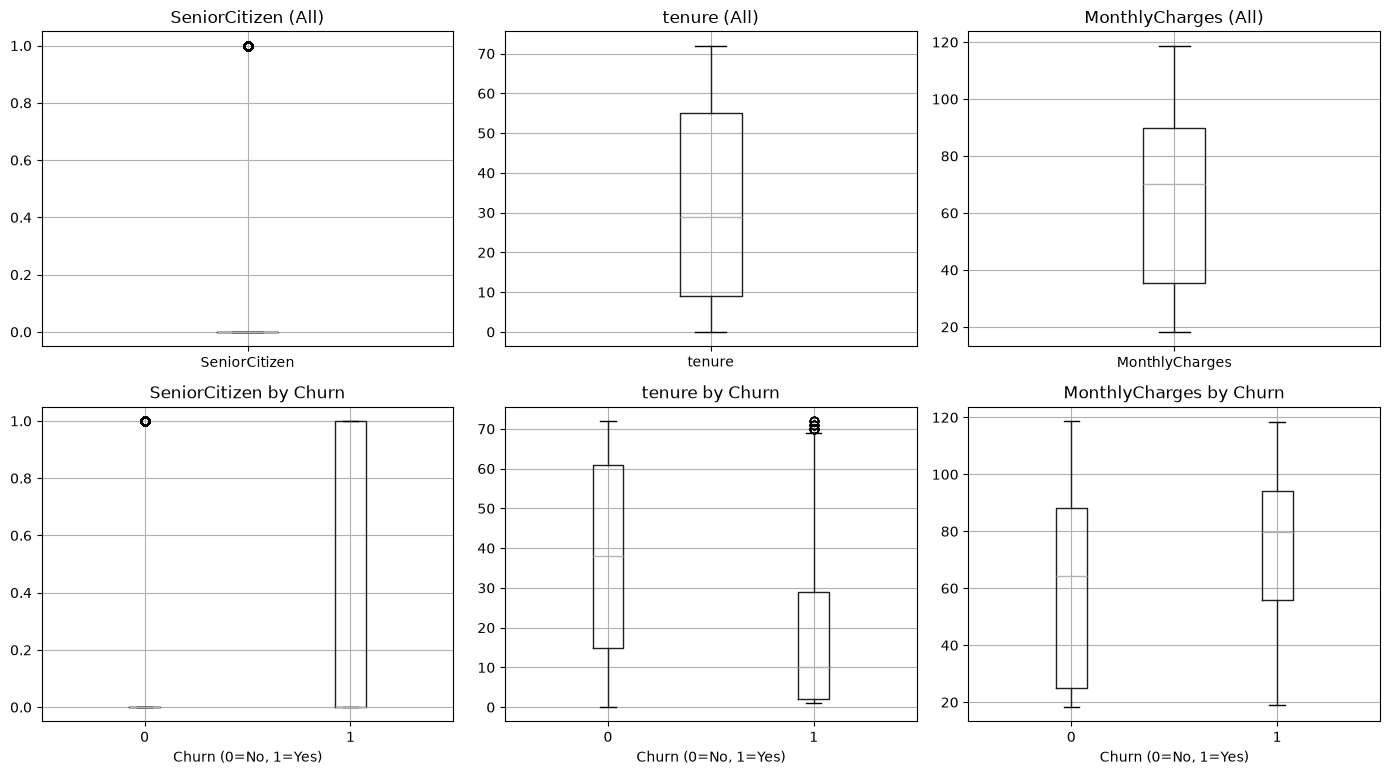


3. Churn 클래스별 IQR 이상치 개수 (제거 시 소수 클래스 영향 확인)


,variable,Churn,n_outliers,class_size,outlier_pct_in_class
0,SeniorCitizen,No(0),666,5174,12.87
1,SeniorCitizen,Yes(1),476,1869,25.47
2,tenure,No(0),0,5174,0.00
3,tenure,Yes(1),0,1869,0.00
4,MonthlyCharges,No(0),0,5174,0.00
5,MonthlyCharges,Yes(1),0,1869,0.00



4. 참고: SeniorCitizen은 0/1 이진 변수 → IQR 이상치 해석 의미 제한적


In [10]:
# churn_prep 수치형 변수 이상치 탐색 (IQR 기준)
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges"]


def iqr_outlier_stats(series, k=1.5):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    mask = (s < low) | (s > high)
    return {
        "count_valid": len(s),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": low,
        "upper_bound": high,
        "n_outliers": mask.sum(),
        "outlier_pct": round(mask.mean() * 100, 2),
    }


print("=" * 60)
print("1. IQR 이상치 요약")
print("=" * 60)
outlier_summary = pd.DataFrame({col: iqr_outlier_stats(churn_prep[col]) for col in num_cols}).T
display(outlier_summary)

print("\n" + "=" * 60)
print("2. Box Plot (전체 + Churn별)")
print("=" * 60)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    churn_prep.boxplot(column=col, ax=axes[0, i])
    axes[0, i].set_title(f"{col} (All)")

    churn_prep.boxplot(column=col, by="Churn", ax=axes[1, i])
    axes[1, i].set_title(f"{col} by Churn")
    axes[1, i].set_xlabel("Churn (0=No, 1=Yes)")

plt.suptitle("")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("3. Churn 클래스별 IQR 이상치 개수 (제거 시 소수 클래스 영향 확인)")
print("=" * 60)
churn_outlier_rows = []
for col in num_cols:
    s = churn_prep[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    is_outlier = (s < low) | (s > high)
    for churn_val, label in [(0, "No(0)"), (1, "Yes(1)")]:
        sub = churn_prep[churn_prep["Churn"] == churn_val]
        out = is_outlier.loc[sub.index].sum()
        churn_outlier_rows.append({
            "variable": col,
            "Churn": label,
            "n_outliers": out,
            "class_size": len(sub),
            "outlier_pct_in_class": round(out / len(sub) * 100, 2),
        })

display(pd.DataFrame(churn_outlier_rows))

print("\n" + "=" * 60)
print("4. 참고: SeniorCitizen은 0/1 이진 변수 → IQR 이상치 해석 의미 제한적")
print("=" * 60)

[AI의 이상치에 대한 해석]
IQR 기준으로는 tenure·MonthlyCharges에 제거할 이상치가 없고, SeniorCitizen 수치는 이진 변수라 무시한다. 따라서 이상치 행 삭제는 하지 않고, 원본(또는 churn_imp)을 유지하는 것이 이 이탈 예측 문제에 더 적합하다.

## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

[프롬프트]
churn_prep의 결측치를 제거하거나 대치할거야. 변수별로 제거와 대치 중 어떤 방법이 적합할지 파악해줘.(대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지?)

[AI의 대답]

## `churn_prep` 결측치 현황 (전처리 후)

| 구분 | 상태 |
|------|------|
| **범주형** (gender, Contract 등) | 원핫 전 `'Missing'`으로 처리됨 → **결측 없음** |
| **남은 결측** | **`tenure` 211건**, **`MonthlyCharges` 211건** 만 존재 |
| **결측 있는 행** | 약 **419행** (6.0%) — 두 변수 결측 행이 완전히 겹치지 않음 |

```
tenure만 결측: 208행
MonthlyCharges만 결측: 208행
둘 다 결측: 3행
```

결측 행의 **Churn 비율(~27.7%)** 은 전체(~26.5%)와 비슷해서, 행 삭제가 클래스 비율을 크게 깨지는 않습니다.

---

## 변수별 권장 방법

### 1) 범주형 변수 (이미 처리됨)

| 방법 | 판단 |
|------|------|
| **행 제거** | ❌ 결측이 여러 컬럼에 흩어져 있어 데이터 손실 큼 |
| **대치** | ✅ 이미 적용한 **`'Missing'` 카테고리** 가 적절 |

→ **값 기반 대치**(“결측” 자체를 하나의 범주로 표현) + One-Hot.  
`InternetService`, `PaymentMethod` 등 원본 결측도 이 방식으로 처리된 상태입니다.

---

### 2) `tenure` (가입 개월 수)

| 방법 | 판단 |
|------|------|
| **행 제거** | △ 가능하나 **~6% 손실** |
| **평균 대치** | △ 분포가 치우쳐 있어 비추천 |
| **중앙값 대치** | ✅ **추천** — 해석 쉽고, 이상치에 강함 |
| **KNN Imputer** | ✅ **추천(더 정교)** — 요금·계약·서비스 변수와 관계 반영 |
| **0으로 채우기** | ❌ “신규 가입”으로 해석할 근거 부족 (결측 행이 꼭 신규는 아님) |

**권장: 중앙값 또는 KNN** (실습에서는 **중앙값**으로 시작, 성능 비교 시 **KNN** 시도)

---

### 3) `MonthlyCharges` (월 요금)

| 방법 | 판단 |
|------|------|
| **행 제거** | △ `tenure`와 동일 |
| **평균 대치** | △ 고요금 쪽 꼬리가 있어 평균이 과대 추정될 수 있음 |
| **중앙값 대치** | ✅ **추천** |
| **KNN Imputer** | ✅ **가장 추천** — 서비스·계약 종류와 요금이 강하게 연관 |

**권장: KNN > 중앙값**  
(원핫 변수가 많아 KNN이 요금을 더 잘 추정하는 경우가 많음)

---

### 4) `tenure` + `MonthlyCharges` 함께 처리할 때

| 전략 | 판단 |
|------|------|
| **컬럼별 따로 행 제거** | ❌ 서로 다른 419행이 깨져 일관성 없음 |
| **419행 통째로 제거** | △ 단순하지만 데이터 6% 손실 |
| **두 컬럼 동시 대치** | ✅ **가장 추천** |

**실무 추천 순서**

1. **기본안:** `tenure`, `MonthlyCharges` 모두 **중앙값 대치**
2. **개선안:** 두 컬럼만 골라 **`KNNImputer(n_neighbors=5)`** (수치형만 fit)
3. **단순안:** 결측 **419행 삭제** — 빠르지만 데이터 손실

---

## 과제용 한 줄 정리

| 변수 | 제거 vs 대치 | 대치 방식 |
|------|-------------|----------|
| 범주형 | **대치** (완료) | **값 기반** (`'Missing'` 범주) |
| `tenure` | **대치** | **중앙값** 또는 **KNN** |
| `MonthlyCharges` | **대치** | **KNN** (또는 중앙값) |
| 행 단위 | 두 수치형만 **같은 기준으로** 처리 | 419행 일괄 삭제는 차선책 |

---

## 구현 예시 (대치 적용 시)

```python
from sklearn.impute import SimpleImputer, KNNImputer

churn_imp = churn_prep.copy()

# 방법 A: 중앙값 대치 (간단)
num_cols = ["tenure", "MonthlyCharges"]
median_imp = SimpleImputer(strategy="median")
churn_imp[num_cols] = median_imp.fit_transform(churn_imp[num_cols])

# 방법 B: KNN 대치 (tenure·MonthlyCharges만)
# knn_imp = KNNImputer(n_neighbors=5)
# churn_imp[num_cols] = knn_imp.fit_transform(churn_imp[num_cols])
```

원하면 이 권장안대로 **결측치 처리 코드를 노트북 `## 2) 결측치 처리` 셀에** 바로 넣어 줄게요.

[프롬프트]
tenure, MonthlyCharges 결측치를 KNN(k=5)으로 채우고 싶어. 둘다 결측인 행은 삭제해줘. 코드는 직접 적지 말고 보여만 줘.

In [12]:
from sklearn.impute import KNNImputer

churn_imp = churn_prep.copy()

num_cols = ["tenure", "MonthlyCharges"]

# 1) tenure·MonthlyCharges 둘 다 결측인 행 삭제
both_missing = churn_imp[num_cols].isnull().all(axis=1)
print(f"둘 다 결측인 행 삭제: {both_missing.sum()}개")
churn_imp = churn_imp.loc[~both_missing].copy()

# 2) 남은 결측은 KNN(k=5)으로 대치
knn_imp = KNNImputer(n_neighbors=5)
churn_imp[num_cols] = knn_imp.fit_transform(churn_imp[num_cols])

# 확인
print("남은 결측치:\n", churn_imp[num_cols].isnull().sum())
print("shape:", churn_imp.shape)

둘 다 결측인 행 삭제: 3개
남은 결측치:
 tenure            0
MonthlyCharges    0
dtype: int64
shape: (7040, 47)


## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

[프롬프트]
변수의 이상치 분포를 살펴보니 churn=1인 그룹에서 tenure(가입개월수)에 이상치가 발생하는 것처럼 보여. 이 data들은 지우는게 나을까? 아니면 남겨둬도 괜찮을까?

[AI의 답변]
**결론부터 말하면, 지우지 않는 편이 좋습니다.**  
박스플롯에서 보이는 점들은 **오류 데이터가 아니라, “오래 이용하다가 이탈한 실제 고객”**에 가깝습니다.

## 왜 Churn=1에서만 이상치처럼 보일까?

박스플롯을 **Churn별로 나눠 그리면**, IQR 기준이 **그룹 안**에서 다시 계산됩니다.

| 그룹 | tenure 특성 |
|------|-------------|
| **Churn=0 (유지)** | 분포가 넓음 (중앙값 약 38개월, 70개월대도 많음) |
| **Churn=1 (이탈)** | 대부분 **초기 이탈** (중앙값 약 10개월, Q3 약 29개월) |

이탈 고객은 대체로 **가입 초기에 떠나는 패턴**이라, 70~72개월 고객 23명이 Churn=1 그룹 기준 IQR 상한(약 69.5)을 넘어 **이상치 점**으로 표시됩니다.

실제 데이터를 보면:

- Churn=1 & tenure 70~72: **23건** (IQR 이상치)
- Churn=1 & tenure ≥ 68: **40건**
- Churn=0 & tenure ≥ 68: **786건**

즉, **장기 고객 중 이탈한 사람은 적지만 존재**하고, 유지 고객 쪽에는 같은 tenure 구간이 훨씬 많습니다.

## 삭제하면 안 되는 이유

**1. 데이터 오류가 아님**  
해당 23건은 Contract, MonthlyCharges, TotalCharges가 모두 자연스럽고, tenure 최댓값 72는 데이터셋 전체 상한과도 일치합니다.

**2. 비즈니스적으로 의미 있는 패턴**  
가입 기간별 이탈률을 보면:

| tenure 구간 | 이탈률(Churn=1 비율) |
|-------------|----------------------|
| 0~12개월 | **47.5%** |
| 13~24개월 | 28.9% |
| 25~36개월 | 21.7% |
| 61~72개월 | **6.6%** |

→ “오래 쓸수록 이탈이 줄어든다”는 **정상적인 인사이트**이고, 70개월대 이탈 고객은 그 중 **소수이지만 중요한 예외**입니다.

**3. 삭제 시 모델이 왜곡됨**  
이탈(Churn=1) 클래스가 이미 소수인데, 장기 이탈 사례까지 제거하면 모델이 **“오래 쓰면 이탈 안 한다”** 쪽으로 과하게 학습할 수 있습니다.  
실제로는 장기 고객도 이탈할 수 있다는 정보를 잃게 됩니다.

**4. 전체 기준으로는 이상치가 아님**  
노트북 IQR 요약에서도 **전체 tenure는 이상치 0건**입니다. Churn=1 서브그룹에서만 상대적으로 튀는 것입니다.

## 실무적으로 어떻게 정리할까?

| 상황 | 권장 |
|------|------|
| **이번 미니프로젝트 (XGBoost 등)** | **그대로 유지** |
| 이상치 “처리”가 필요하다고 적을 때 | “제거”가 아니라 **“Churn=1 내 상대적 이상치이나, 유효한 장기 이탈 사례로 유지”** 로 기록 |
| 거리 기반 모델 (KNN, SVM, SVDD 등) | 제거 대신 **스케일링** 또는 **tenure 구간화** 고려 |

```python
# 예: tenure 구간 변수 (삭제 대신 패턴 포착)
churn_prep["tenure_group"] = pd.cut(
    churn_prep["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)
```

## 언제 삭제를 고려하나?

아래일 때만 제거를 검토합니다.

- 입력 오류 (예: tenure가 999, 음수)
- 도메인 지식으로 **불가능한 조합**이 확인될 때
- 측정/수집 오류가 명확할 때

이번 케이스는 해당하지 않습니다.

---

**과제 답안 요약:**  
Churn=1 그룹의 tenure 이상치는 **통계적 이상치(statistical outlier)** 이지 **데이터 오류(outlier error)** 가 아닙니다. **삭제하지 말고 유지**하는 것이 맞고, “이탈은 주로 초기에 많지만, 장기 이용 후 이탈하는 소수 그룹도 존재한다”는 점을 EDA 해석에 적어 두면 좋습니다.

## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

[프롬프트]
모델 구축 전 train/test 데이터 그룹을 나눌거야. 시계열데이터는 아닌것 같고, 클래스 불균형이 있으니 stratify=Y 옵션을 적용하면 좋겠지? 코드는 채팅창에만 적어줘.

[AI의 대답]
맞습니다. 이 데이터는 시계열이 아닌 횡단면(cross-sectional) 데이터이고, Churn 비율이 No ~73% / Yes ~27% 로 불균형하므로 stratify=y 로 나누는 것이 좋습니다.

- shuffle=True(기본값) 사용 OK — 시간 순서를 지킬 필요 없음
- stratify=y → train/test 양쪽에서 Churn 비율이 비슷하게 유지됨

In [13]:
# X, y 분리
X = churn_imp.drop(columns=["Churn"])
y = churn_imp["Churn"]

# train / test 분할 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 분할 결과 확인
print("train:", X_train.shape, "| test:", X_test.shape)
print("\n[train] Churn 비율")
print(y_train.value_counts(normalize=True).round(3))
print("\n[test] Churn 비율")
print(y_test.value_counts(normalize=True).round(3))

train: (5632, 46) | test: (1408, 46)

[train] Churn 비율
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

[test] Churn 비율
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

[프롬프트]
분할한 데이터에 스케일링이 필요한지 확인해줘. (인코딩은 이미 적용됨)

[AI의 대답]
**결론부터:** 인코딩은 끝났지만, **이 미니프로젝트 전체를 보면 스케일링이 필요합니다.**  
다만 **모든 모델에 필수는 아니고**, 쓸 모델에 따라 다릅니다.

---

## 현재 `X`의 형태

| 변수 종류 | 예시 | 값 범위 |
|----------|------|--------|
| 원핫 범주형 | `Contract_…`, `InternetService_…` | 0 / 1 |
| 이진 수치 | `SeniorCitizen` | 0 / 1 |
| 연속 수치 | `tenure` | 약 0 ~ 72 |
| 연속 수치 | `MonthlyCharges` | 약 20 ~ 120 |

`tenure`, `MonthlyCharges`는 0~1인 원핫 변수보다 **스케일이 훨씬 큽니다.**

---

## 모델별로 보면

| 사용 예정 기법 | 스케일링 필요? | 이유 |
|---------------|---------------|------|
| **XGBoost** | **불필요** | 트리는 분할만 하므로 스케일에 둔감 |
| **SMOTE / ADASYN / TomekLinks** | **필요** | 이웃·거리 기반 → 큰 변수가 지배 |
| **t-SNE** | **필요** | 거리 기반 시각화 |
| **One-Class SVM (SVDD)** | **거의 필수** | RBF 커널·거리 기반 |

이 프로젝트는 **Resampling + t-SNE + SVDD**까지 하므로, **스케일링을 하는 편이 맞습니다.**

---

## 어떻게 스케일링할까?

### 추천: `StandardScaler` + **train만 fit**

```python
# train으로 fit → train/test transform (데이터 누수 방지)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

### 스케일링 범위

| 방식 | 설명 |
|------|------|
| **전체 feature에 적용** (실습에서 흔함) | 구현 단순, SMOTE·SVM·t-SNE에 보통 충분 |
| **수치형만 적용** (`tenure`, `MonthlyCharges`) | 원핫 0/1 유지, 이론적으로 더 깔끔 |

원핫까지 스케일해도 0/1이 약간 바뀌지만, **실습 수준에서는 전체 스케일링으로도 무방**합니다.

---

## 주의사항

1. **`fit`은 `X_train`만** — test 정보가 섞이면 안 됨  
2. **Resampling(SMOTE 등)은 스케일링 후, train에만** 적용  
3. **XGBoost만 단독 비교**할 때는 스케일 안 된 데이터로도 가능  
4. 비교 표를 만들 때는 **같은 전처리 파이프라인**을 쓰는 것이 공정함  

---

## 과제용 한 줄

> 인코딩은 완료되었고, **XGBoost만 쓸 때는 스케일링이 필수는 아니지만**, SMOTE·t-SNE·SVDD를 쓰므로 **`StandardScaler`로 train fit 후 train/test transform 하는 것이 적절**하다.

원하면 **스케일링 + `X_train_scaled` 저장** 코드도 채팅에만 적어 줄게요.

In [ ]:
X_train

,SeniorCitizen,tenure,MonthlyCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_Missing
6679,0,60.0,37.70,True,False,False,True,True,False,True,...,False,False,True,True,False,True,False,False,False,False
3152,0,26.0,95.85,True,False,True,False,True,False,False,...,False,True,False,False,True,True,False,False,False,False
1953,0,1.0,75.35,False,True,True,False,False,True,False,...,True,False,False,False,True,False,False,True,False,False
6386,0,72.0,83.55,False,True,False,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
3810,0,1.0,44.55,False,True,False,True,False,True,False,...,True,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3492,0,3.0,29.20,True,False,True,False,True,False,True,...,True,False,False,True,False,False,False,False,True,False
635,0,45.0,105.50,True,False,False,True,False,True,False,...,True,False,False,False,True,False,False,True,False,False
1054,0,40.0,97.10,False,True,False,True,True,False,False,...,True,False,False,False,True,True,False,False,False,False
6055,0,6.0,55.00,True,False,True,False,True,False,False,...,True,False,False,False,True,False,False,True,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1) scaler는 train으로만 fit
scaler = StandardScaler()  #표준화 방법으로 스케일링. IQR 이상치가 거의 없어 RobustScaler까지는 필요하지 않다.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  #fit은 X_train만, transform은 train·test 모두에 적용

# 2) DataFrame으로 저장 (컬럼명 유지 — SMOTE/SVM 등에서 편함)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# 3) 확인
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
display(X_train_scaled.describe().T.head())

X_train_scaled: (5632, 46)
X_test_scaled : (1408, 46)


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5632.0,-1.766264e-17,1.000089,-0.437842,-0.437842,-0.437842,-0.437842,2.283930
tenure,5632.0,3.280204e-17,1.000089,-1.327753,-0.957966,-0.136217,0.932056,1.630542
MonthlyCharges,5632.0,-2.264603e-16,1.000089,-1.569489,-0.856413,0.181512,0.829534,1.804924
gender_Female,5632.0,6.181924e-17,1.000089,-0.991513,-0.991513,-0.991513,1.008559,1.008559
gender_Male,5632.0,-6.181924e-17,1.000089,-1.008559,-1.008559,0.991513,0.991513,0.991513


In [17]:
X_train_scaled

,SeniorCitizen,tenure,MonthlyCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_Missing
6679,-0.437842,1.137493,-0.916431,1.008559,-1.008559,-1.032488,1.032488,0.656979,-0.656979,3.073919,...,-1.104511,-0.518691,1.787064,1.208941,-1.208941,1.932039,-0.509582,-0.697711,-0.538487,-0.176955
3152,-0.437842,-0.259480,1.036028,1.008559,-1.008559,0.968535,-0.968535,0.656979,-0.656979,-0.325318,...,-1.104511,1.927931,-0.559577,-0.827170,0.827170,1.932039,-0.509582,-0.697711,-0.538487,-0.176955
1953,-0.437842,-1.286666,0.347715,-0.991513,0.991513,0.968535,-0.968535,-1.522118,1.522118,-0.325318,...,0.905378,-0.518691,-0.559577,-0.827170,0.827170,-0.517588,-0.509582,1.433259,-0.538487,-0.176955
6386,-0.437842,1.630542,0.623040,-0.991513,0.991513,-1.032488,1.032488,-1.522118,1.522118,-0.325318,...,-1.104511,-0.518691,1.787064,-0.827170,0.827170,-0.517588,1.962394,-0.697711,-0.538487,-0.176955
3810,-0.437842,-1.286666,-0.686433,-0.991513,0.991513,-1.032488,1.032488,-1.522118,1.522118,-0.325318,...,0.905378,-0.518691,-0.559577,1.208941,-1.208941,-0.517588,-0.509582,1.433259,-0.538487,-0.176955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3492,-0.437842,-1.204491,-1.201829,1.008559,-1.008559,0.968535,-0.968535,0.656979,-0.656979,3.073919,...,0.905378,-0.518691,-0.559577,1.208941,-1.208941,-0.517588,-0.509582,-0.697711,1.857056,-0.176955
635,-0.437842,0.521182,1.360039,1.008559,-1.008559,-1.032488,1.032488,-1.522118,1.522118,-0.325318,...,0.905378,-0.518691,-0.559577,-0.827170,0.827170,-0.517588,-0.509582,1.433259,-0.538487,-0.176955
1054,-0.437842,0.315744,1.077998,-0.991513,0.991513,-1.032488,1.032488,0.656979,-0.656979,-0.325318,...,0.905378,-0.518691,-0.559577,-0.827170,0.827170,1.932039,-0.509582,-0.697711,-0.538487,-0.176955
6055,-0.437842,-1.081228,-0.335562,1.008559,-1.008559,0.968535,-0.968535,0.656979,-0.656979,-0.325318,...,0.905378,-0.518691,-0.559577,-0.827170,0.827170,-0.517588,-0.509582,1.433259,-0.538487,-0.176955


## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

[프롬프트]
Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 확인할거야. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 확인하는 코드를 적어줘.

[AI의 t-SNE 해석 팁]
- 주황(Churn)이 파랑(No Churn) 안에 많이 섞이면 → 클래스가 잘 안 갈라짐 → Resampling만으로는 한계, SVDD 검토 가치 있음
- 어느 정도 뭉치면 → 지도 학습 + Resampling도 의미 있음

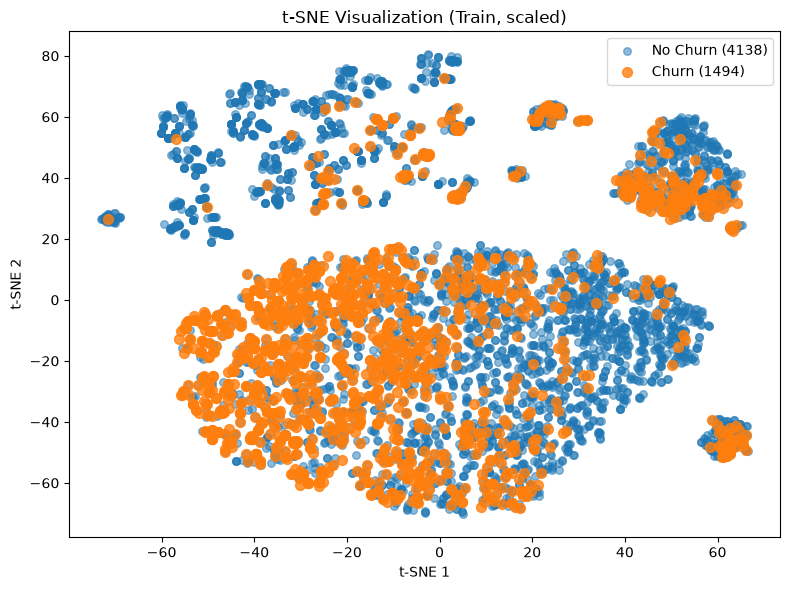

In [18]:
# t-SNE: Churn(0/1) 클래스가 2D에서 얼마나 겹치는지 확인
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42,
)

X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1],
    label=f"No Churn ({(y_train == 0).sum()})",
    alpha=0.5,
    s=30,
)
plt.scatter(
    X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1],
    label=f"Churn ({(y_train == 1).sum()})",
    alpha=0.8,
    s=50,
)
plt.title("t-SNE Visualization (Train, scaled)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

,Before,TomekLinks,SMOTE,SMOTE+Tomek,ADASYN
No Churn(0),4138,3711,4138,3920,4138
Churn(1),1494,1494,4138,3920,4133


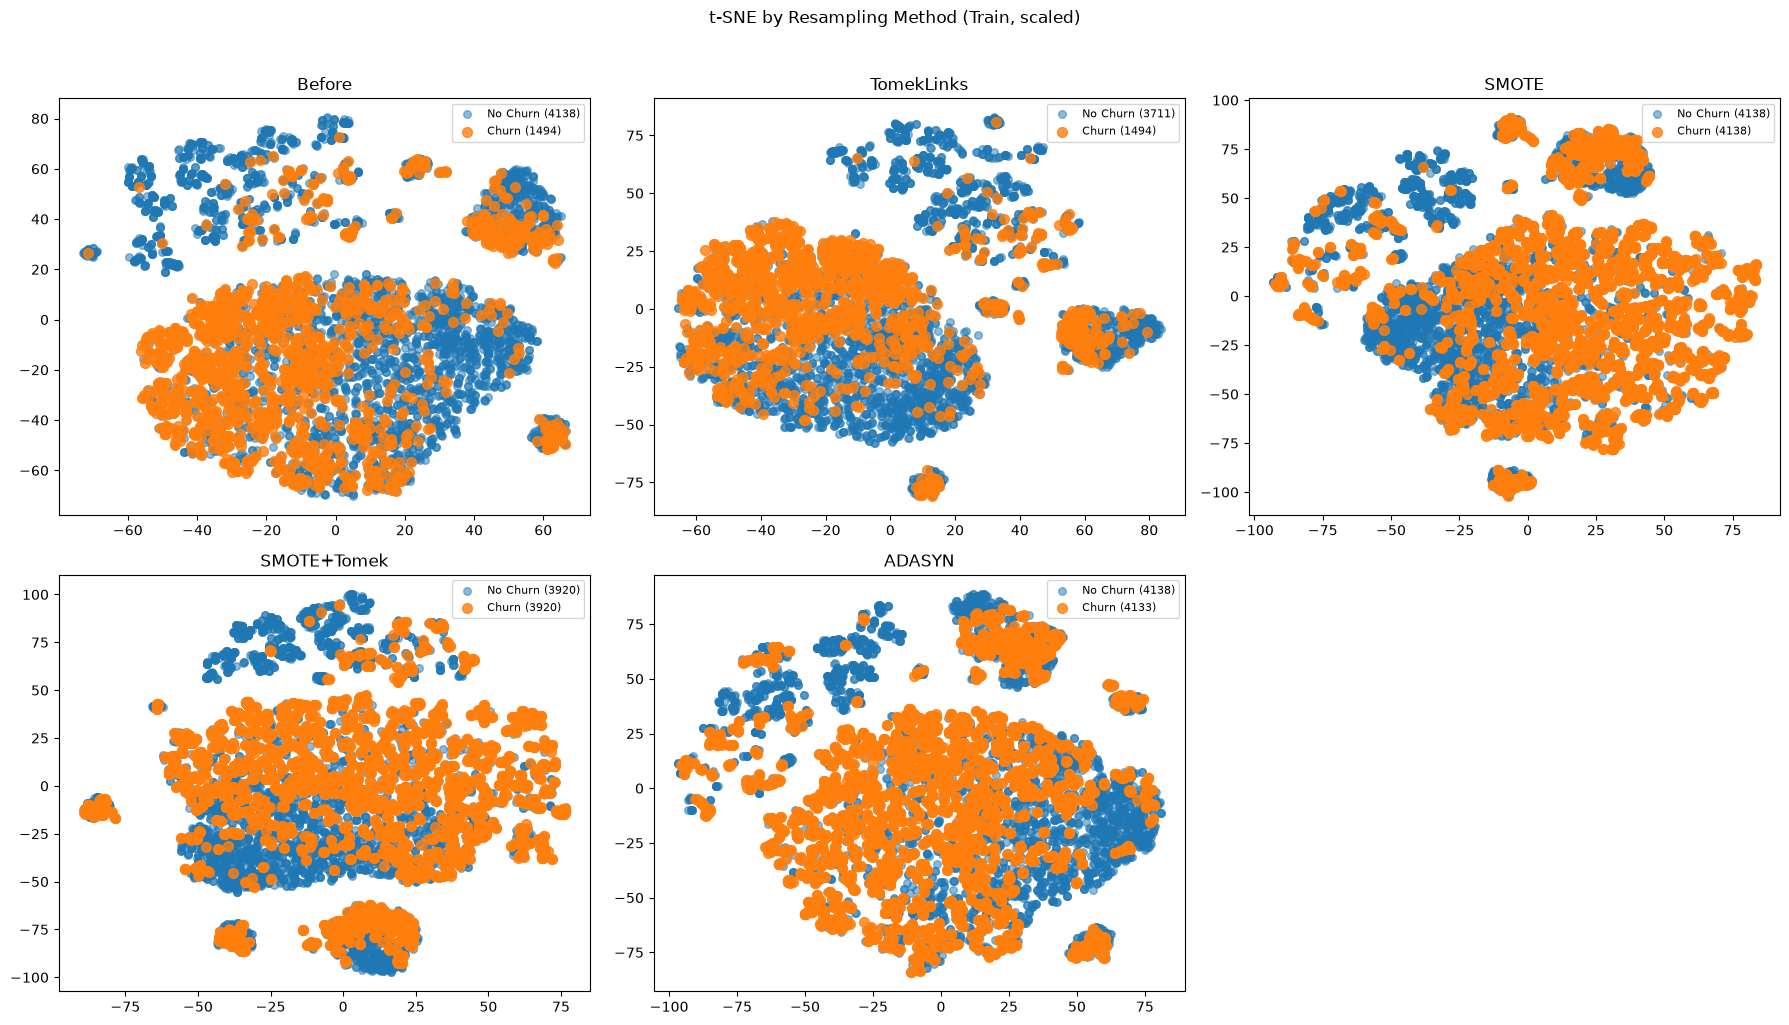

In [19]:
# ── Resampling (train only) ──
NO, CHURN = 0, 1  # No Churn=0, Churn=1

X_tl, y_tl = TomekLinks().fit_resample(X_train_scaled, y_train)
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)
X_smt, y_smt = SMOTETomek(random_state=42).fit_resample(X_train_scaled, y_train)
X_ada, y_ada = ADASYN(random_state=42).fit_resample(X_train_scaled, y_train)

# 클래스 수 변화 확인
compare_resample = pd.DataFrame({
    "Before": y_train.value_counts().sort_index(),
    "TomekLinks": pd.Series(y_tl).value_counts().sort_index(),
    "SMOTE": pd.Series(y_sm).value_counts().sort_index(),
    "SMOTE+Tomek": pd.Series(y_smt).value_counts().sort_index(),
    "ADASYN": pd.Series(y_ada).value_counts().sort_index(),
})
compare_resample.index = ["No Churn(0)", "Churn(1)"]
display(compare_resample)

# ── t-SNE 비교 시각화 ──
sampling_datasets = {
    "Before": (X_train_scaled, y_train),
    "TomekLinks": (X_tl, y_tl),
    "SMOTE": (X_sm, y_sm),
    "SMOTE+Tomek": (X_smt, y_smt),
    "ADASYN": (X_ada, y_ada),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, y_s)) in enumerate(sampling_datasets.items()):
    y_s = pd.Series(y_s).reset_index(drop=True)
    emb = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="random",
        random_state=42,
    ).fit_transform(X_s)

    axes[i].scatter(
        emb[y_s == NO, 0], emb[y_s == NO, 1],
        label=f"No Churn ({(y_s == NO).sum()})",
        alpha=0.5, s=30,
    )
    axes[i].scatter(
        emb[y_s == CHURN, 0], emb[y_s == CHURN, 1],
        label=f"Churn ({(y_s == CHURN).sum()})",
        alpha=0.8, s=50,
    )
    axes[i].set_title(name)
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
plt.suptitle("t-SNE by Resampling Method (Train, scaled)", y=1.02)
plt.tight_layout()
plt.show()

모든 resampling 결과가 큰 의미가 없어보이는데...

**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

[프롬프트]
Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하고 싶어.

In [20]:
# Resampling 기법별 XGBoost 성능 비교 (평가: 원본 test)
train_sets = {
    "Before": (X_train_scaled, y_train),
    "TomekLinks": (X_tl, y_tl),
    "SMOTE": (X_sm, y_sm),
    "SMOTE+Tomek": (X_smt, y_smt),
    "ADASYN": (X_ada, y_ada),
}

results = []
for name, (X_tr, y_tr) in train_sets.items():
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    )
    model.fit(X_tr, y_tr)
    pred = model.predict(X_test_scaled)

    results.append({
        "Method": name,
        "Precision": round(precision_score(y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(y_test, pred, pos_label=1), 4),
    })

xgb_results = pd.DataFrame(results)
display(xgb_results)

,Method,Precision,Recall,F1-score
0,Before,0.6288,0.5481,0.5857
1,TomekLinks,0.5813,0.6310,0.6051
2,SMOTE,0.5645,0.6551,0.6064
3,SMOTE+Tomek,0.5843,0.6578,0.6189
4,ADASYN,0.5810,0.6524,0.6146


## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

[프롬프트]
Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨까?
1. One-Class SVM(SVDD)을 정상 데이터로만 학습시켜줘.
2. Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 분석을 위한 코드를 작성해줘.

학습 데이터 (No Churn만): (4138, 46)

[예측 분포]
-1     186
 1    1222
Name: count, dtype: int64

[성능 지표] (이상 클래스 = Churn, pos_label=-1)
Precision: 0.2957
Recall   : 0.1471
F1-score : 0.1964

[classification_report]
              precision    recall  f1-score   support

   Normal(1)       0.30      0.15      0.20       374
   Churn(-1)       0.74      0.87      0.80      1034

    accuracy                           0.68      1408
   macro avg       0.52      0.51      0.50      1408
weighted avg       0.62      0.68      0.64      1408


[경계 밖/안 분류 요약]


,건수,비율(%)
Churn → outlier(-1) [Recall],55,14.71
Churn → inlier(1) [놓침],319,85.29
No Churn → inlier(1) [정상],903,87.33
No Churn → outlier(-1) [오탐],131,12.67


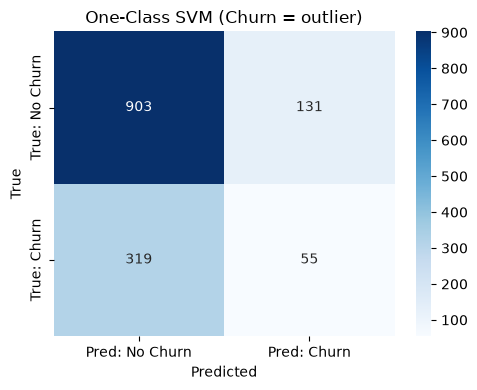

In [21]:
# ── 1) One-Class SVM: 정상(Non-Churn)만 학습 ──
X_train_normal = X_train_scaled[y_train == 0]
print("학습 데이터 (No Churn만):", X_train_normal.shape)

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train_normal)

# ── 2) test 예측 (정상+이탈 모두) ──
# OneClassSVM:  1 = inlier(정상), -1 = outlier(이상)
y_pred_oc = oc_svm.predict(X_test_scaled)

# 평가용 라벨 변환 (Day 4-3과 동일)
# 실제: No Churn(0)→1(정상), Churn(1)→-1(이상)
y_test_oc = y_test.map({0: 1, 1: -1})

print("\n[예측 분포]")
print(pd.Series(y_pred_oc).value_counts().sort_index())

print("\n[성능 지표] (이상 클래스 = Churn, pos_label=-1)")
print("Precision:", round(precision_score(y_test_oc, y_pred_oc, pos_label=-1), 4))
print("Recall   :", round(recall_score(y_test_oc, y_pred_oc, pos_label=-1), 4))
print("F1-score :", round(f1_score(y_test_oc, y_pred_oc, pos_label=-1), 4))

print("\n[classification_report]")
print(classification_report(y_test_oc, y_pred_oc, target_names=["Normal(1)", "Churn(-1)"]))

# ── 3) Churn이 경계 밖으로 걸러지는지 상세 분석 ──
churn_total = (y_test == 1).sum()
churn_detected = ((y_test == 1) & (y_pred_oc == -1)).sum()   # 이탈 → outlier (정답)
churn_missed = ((y_test == 1) & (y_pred_oc == 1)).sum()     # 이탈인데 정상으로 판단

normal_total = (y_test == 0).sum()
normal_correct = ((y_test == 0) & (y_pred_oc == 1)).sum()   # 유지 → inlier (정답)
normal_false_alarm = ((y_test == 0) & (y_pred_oc == -1)).sum()  # 유지인데 이탈로 오판

summary_oc = pd.DataFrame({
    "건수": [churn_detected, churn_missed, normal_correct, normal_false_alarm],
    "비율(%)": [
        round(churn_detected / churn_total * 100, 2),
        round(churn_missed / churn_total * 100, 2),
        round(normal_correct / normal_total * 100, 2),
        round(normal_false_alarm / normal_total * 100, 2),
    ],
}, index=[
    "Churn → outlier(-1) [Recall]",
    "Churn → inlier(1) [놓침]",
    "No Churn → inlier(1) [정상]",
    "No Churn → outlier(-1) [오탐]",
])
print("\n[경계 밖/안 분류 요약]")
display(summary_oc)

# 혼동 행렬 (실제 Churn 0/1 기준)
cm = confusion_matrix(y_test, (y_pred_oc == -1).astype(int))
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: No Churn", "Pred: Churn"],
    yticklabels=["True: No Churn", "True: Churn"],
)
plt.title("One-Class SVM (Churn = outlier)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Day 4-3 SVDD 패턴에 맞춰, **정상(Churn=0)만 학습**하고 **test에서 이탈(Churn=1)이 경계 밖(-1)으로 잡히는지** 보는 코드입니다.

## 해석 가이드

| 지표 | 의미 |
|------|------|
| **Recall (pos_label=-1)** | 실제 Churn 중 **경계 밖(outlier)으로 잡힌 비율** |
| **Precision (pos_label=-1)** | outlier로 예측한 것 중 **진짜 Churn 비율** |
| **Churn → inlier(1)** | 이탈 고객을 **놓친 경우** |
| **No Churn → outlier(-1)** | 유지 고객을 **이탈로 오탐**한 경우 |

---

## Resampling XGBoost와 비교할 때

- SVDD는 **이탈(Churn=1)을 outlier(-1)로 잡는지**가 핵심입니다.
- t-SNE에서 클래스가 많이 겹쳤다면 **Recall이 Resampling보다 낮을 수도** 있습니다.
- `nu`를 바꾸면 경계가 달라지므로, 다음 과제에서 `nu`별 비교를 이어가면 됩니다.

**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

[프롬프트]
nu값은 어떤 값들을 넣어보면 좋을까? nu값에 따라 SVDD의 경계외 성능이 어떻게 달라지는지 확인할 수 있게 시각화 코드를 짜줘.

,nu,Precision,Recall,F1-score
0,0.01,0.3070,0.0936,0.1434
1,0.05,0.3065,0.1016,0.1526
2,0.10,0.2957,0.1471,0.1964
3,0.15,0.2720,0.1818,0.2179
4,0.20,0.2761,0.2406,0.2571
5,0.30,0.2721,0.3209,0.2945
6,0.50,0.2543,0.4759,0.3315


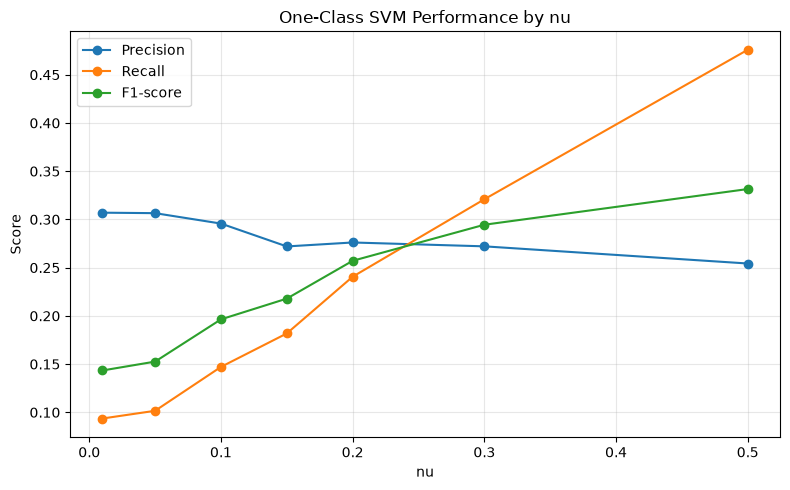

c:\Users\Admin\miniconda3\envs\day4\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but OneClassSVM was fitted without feature names
  warnings.warn(


ValueError: X has 46 features, but OneClassSVM is expecting 2 features as input.

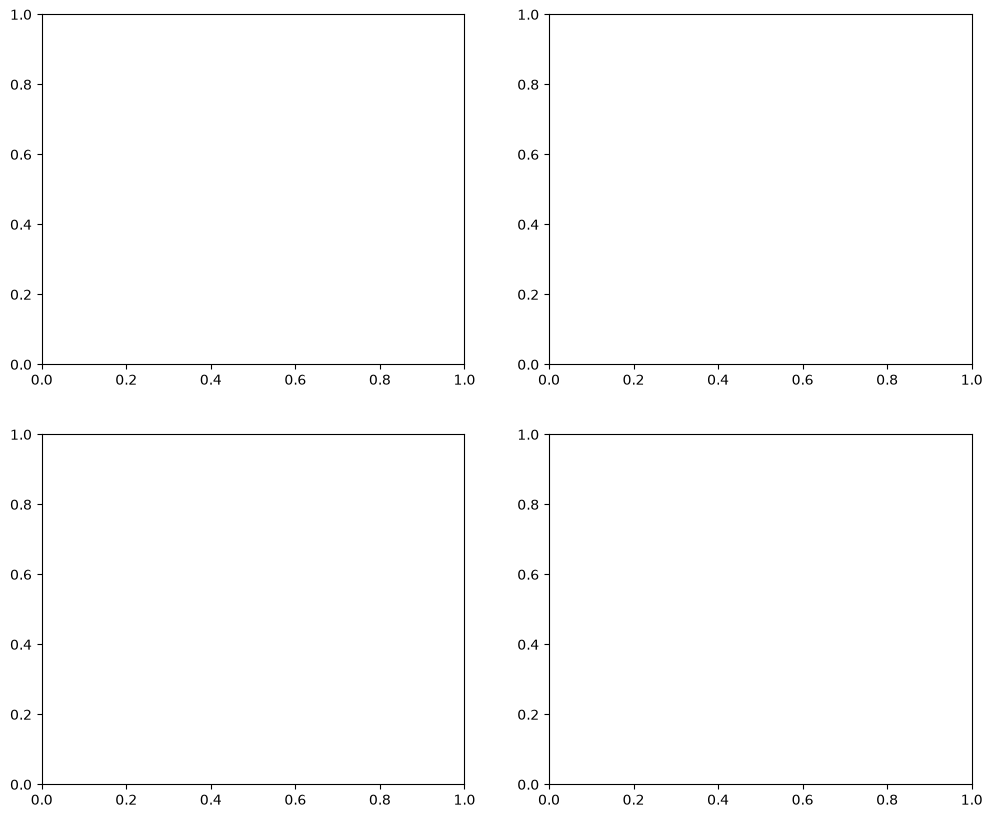

In [24]:
from sklearn.decomposition import PCA

# ── 1) 성능: nu별 F1 / Recall / Precision ──
nu_list = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
X_train_normal = X_train_scaled[y_train == 0]
y_test_oc = y_test.map({0: 1, 1: -1})

nu_results = []
for nu in nu_list:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train_normal)
    pred = model.predict(X_test_scaled)

    nu_results.append({
        "nu": nu,
        "Precision": round(precision_score(y_test_oc, pred, pos_label=-1), 4),
        "Recall": round(recall_score(y_test_oc, pred, pos_label=-1), 4),
        "F1-score": round(f1_score(y_test_oc, pred, pos_label=-1), 4),
    })

nu_df = pd.DataFrame(nu_results)
display(nu_df)

# 성능 곡선
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(nu_df["nu"], nu_df["Precision"], marker="o", label="Precision")
ax.plot(nu_df["nu"], nu_df["Recall"], marker="o", label="Recall")
ax.plot(nu_df["nu"], nu_df["F1-score"], marker="o", label="F1-score")
ax.set_xlabel("nu")
ax.set_ylabel("Score")
ax.set_title("One-Class SVM Performance by nu")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2) 경계 시각화: PCA 2D + nu별 decision boundary ──
pca = PCA(n_components=2, random_state=42)
X_normal_pca = pca.fit_transform(X_train_normal)
X_test_pca = pca.transform(X_test_scaled)

nu_plot = [0.01, 0.1, 0.3, 0.5]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)

for ax, nu in zip(axes, nu_plot):
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_normal_pca)

    pred_full = model.predict(X_test_scaled)  # 성능은 전체 feature 기준
    f1 = f1_score(y_test_oc, pred_full, pos_label=-1)

    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors="red")

    ax.scatter(
        X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1],
        c="steelblue", alpha=0.4, s=20, label="No Churn",
    )
    ax.scatter(
        X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1],
        c="coral", alpha=0.8, s=40, label="Churn",
    )
    ax.set_title(f"nu={nu} (F1={f1:.3f})")
    ax.legend(fontsize=8)

plt.suptitle("SVDD Boundary in PCA 2D (red = boundary)", y=1.02)
plt.tight_layout()
plt.show()

## `nu` 추천 값

Day 4-3와 같은 맥락으로 아래를 쓰면 됩니다.

| nu | 경계 성향 | 확인 포인트 |
|----|----------|------------|
| **0.01** | 넓음 (과소적합) | Churn을 많이 **놓침** (Recall ↓) |
| **0.05 ~ 0.1** | 보통 | **기본 비교값** (`0.1` 권장) |
| **0.15 ~ 0.2** | 조금 타이트 | Recall·Precision 균형 탐색 |
| **0.3 ~ 0.5** | 좁음 (과적합) | 정상 고객 **오탐** 증가 |

**추천 탐색 범위:** `[0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]`  
**시각화용 대표 4개:** `[0.01, 0.1, 0.3, 0.5]`

고차원(47변수)이라 **경계는 PCA 2D 공간**에 그리고, **성능은 전체 feature**로 평가하는 방식이 실습에 맞습니다.

---

## 해석 팁

**성능 곡선**
- **nu ↑** → 경계 좁아짐 → **Recall ↑** (Churn을 더 잘 잡음), **Precision ↓** (정상 오탐 증가) 경향

**PCA 경계 그림**
- 빨간 선 = 정상 영역 경계 (안쪽 inlier, 바깥 outlier)
- **nu 작을수록** 경계가 넓어져 Churn(주황)이 안쪽에 더 많이 들어옴
- **nu 클수록** 경계가 조여져 Churn이 바깥으로 밀리지만, No Churn도 바깥으로 나갈 수 있음

PCA 2D는 **대략적인** 경계 형태만 보여 주므로, 최종 판단은 **위 성능 표/곡선**을 기준으로 하면 됩니다.

## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.